# Experiment 04: Class-weighted Hybrid Chen Loss + Multi-region Crop Input Comparison

This notebook continues from the selected loss and imbalance strategy:

- **Model backbone:** DenseNet121
- **Loss:** Class-weighted HybridChenOrdinalLoss
- **Input change:** single full X-ray image → multi-region crop inputs
- **Goal:** compare different anatomical crop strategies for knee OA severity grading.

The main 4-crop design uses:

1. `wide`: overall knee joint structure  
2. `center`: central joint space  
3. `left_edge`: left edge region  
4. `right_edge`: right edge region  

This is important for OA grading because the model should consider both **joint space narrowing** and **edge osteophytes**, not only the whole image.

## 1. Imports & Environment Setup

In [70]:
from pathlib import Path
import os
import random
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets

from sklearn.metrics import (
   accuracy_score,
   f1_score,
   confusion_matrix,
   classification_report,
   cohen_kappa_score
)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration Section

All experiment parameters are kept in one configuration block for reproducibility.

In [71]:
CONFIG = {
   "IMG_SIZE": 224,
   "BATCH_SIZE": 16,
   "EPOCHS": 30,
   "LR": 1e-4,
   "SEED": 42,
   "MODEL_NAME": "DenseNet121",
   "LOSS": "ClassWeightedHybridChenOrdinalLoss",
   "NUM_CLASSES": 5,
   "DROPOUT": 0.3,
   "WEIGHT_DECAY": 0.0,
   "PATIENCE": 7,
   "PENALTY_DISTANCE": 2,
   "ORDINAL_ALPHA": 0.10,
   "SQUARE_LOSS": False,
   "NORMALIZE_MATRIX": True,
}

# Crop modes to compare.
# This keeps the same DenseNet121 backbone and same class-weighted hybrid loss.
CROP_EXPERIMENTS = [
    {
        "name": "single_wide",
        "description": "Single full X-ray image only.",
        "crop_names": ["wide"],
    },
    {
        "name": "center_only",
        "description": "Central joint-space crop only.",
        "crop_names": ["center"],
    },
    {
        "name": "wide_center_2crop",
        "description": "Full image plus central joint-space crop.",
        "crop_names": ["wide", "center"],
    },
    {
        "name": "wide_center_edges_4crop",
        "description": "Full image, central joint space, left edge, and right edge.",
        "crop_names": ["wide", "center", "left_edge", "right_edge"],
    },
]

# Set this to a subset if you want to test quickly.
RUN_EXPERIMENT_NAMES = [exp["name"] for exp in CROP_EXPERIMENTS]

OUTPUT_DIR = Path("/kaggle/working/exp04_crop_comparison_classweighted_hybridchen")
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
RESULTS_DIR = OUTPUT_DIR / "results"

for p in [OUTPUT_DIR, FIGURES_DIR, MODELS_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("CONFIG:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

print("\nCrop experiments:")
for exp in CROP_EXPERIMENTS:
    print(f"- {exp['name']}: {exp['crop_names']} | {exp['description']}")

print("\nOutput directory:", OUTPUT_DIR)

CONFIG:
  IMG_SIZE: 224
  BATCH_SIZE: 16
  EPOCHS: 30
  LR: 0.0001
  SEED: 42
  MODEL_NAME: DenseNet121
  LOSS: ClassWeightedHybridChenOrdinalLoss
  NUM_CLASSES: 5
  DROPOUT: 0.3
  WEIGHT_DECAY: 0.0
  PATIENCE: 7
  PENALTY_DISTANCE: 2
  ORDINAL_ALPHA: 0.1
  SQUARE_LOSS: False
  NORMALIZE_MATRIX: True

Crop experiments:
- single_wide: ['wide'] | Single full X-ray image only.
- center_only: ['center'] | Central joint-space crop only.
- wide_center_2crop: ['wide', 'center'] | Full image plus central joint-space crop.
- wide_center_edges_4crop: ['wide', 'center', 'left_edge', 'right_edge'] | Full image, central joint space, left edge, and right edge.

Output directory: /kaggle/working/exp04_crop_comparison_classweighted_hybridchen


## 3. Dataset Paths

The Kaggle dataset should contain:

```text
/kaggle/input/datasets/joylyuyue/split-data/train
/kaggle/input/datasets/joylyuyue/split-data/val
/kaggle/input/datasets/joylyuyue/split-data/test
```

In [72]:
# Change this path to your own dataset folder.
# The folder should contain train/, val/, and test/.
DATA_ROOT = Path("/kaggle/input/YOUR_DATASET_NAME/split-data")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not d.exists():
        raise FileNotFoundError(f"Missing folder: {d}")

print("Dataset paths are valid.")

DATA_ROOT: /kaggle/input/datasets/joylyuyue/split-data
TRAIN_DIR: /kaggle/input/datasets/joylyuyue/split-data/train
VAL_DIR: /kaggle/input/datasets/joylyuyue/split-data/val
TEST_DIR: /kaggle/input/datasets/joylyuyue/split-data/test
Dataset paths are valid.


## 4. Seed Fixing

In [73]:
def set_seed(seed=42):
   random.seed(seed)
   np.random.seed(seed)
   torch.manual_seed(seed)
   torch.cuda.manual_seed_all(seed)
   torch.backends.cudnn.deterministic = False
   torch.backends.cudnn.benchmark = True

set_seed(CONFIG["SEED"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 5. Data Preprocessing

For this experiment, **no random data augmentation** is applied.  
The goal is to isolate the effect of changing the input representation from a single full image to multi-region crops.

Preprocessing includes:

- resize
- tensor conversion
- ImageNet-style normalization

CLAHE is shown only as a preview for medical-image inspection. It is **not used for training** in this experiment.

In [74]:
# Deterministic preprocessing only.
# No random augmentation is used in this crop-comparison experiment.

normalize_mean = [0.485, 0.485, 0.485]
normalize_std = [0.229, 0.229, 0.229]

single_image_transform = transforms.Compose([
    transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_mean, std=normalize_std),
])

def denormalize_tensor(img_tensor, mean=normalize_mean, std=normalize_std):
    img = img_tensor.detach().cpu().clone()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img = img * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

print("Preprocessing: Resize -> ToTensor -> Normalize")
print("No data augmentation is used.")

Preprocessing: Resize -> ToTensor -> Normalize
No data augmentation is used.


## 6. Dataset & Dataloader

This section first loads raw `ImageFolder` datasets to check the split sizes and class distribution.  
Then a custom multi-region crop dataset is used for each crop experiment.

In [75]:
# Raw ImageFolder datasets are used for checking split sizes and class distribution.
train_raw = datasets.ImageFolder(TRAIN_DIR, transform=None)
val_raw = datasets.ImageFolder(VAL_DIR, transform=None)
test_raw = datasets.ImageFolder(TEST_DIR, transform=None)

class_names = train_raw.classes
class_to_idx = train_raw.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Class mapping:", class_to_idx)
print("Train size:", len(train_raw))
print("Val size:", len(val_raw))
print("Test size:", len(test_raw))

def get_class_counts(raw_dataset, split_name):
    targets = np.array(raw_dataset.targets)
    counts = np.bincount(targets, minlength=len(raw_dataset.classes))
    rows = []
    for i, c in enumerate(raw_dataset.classes):
        rows.append({
            "split": split_name,
            "class_idx": i,
            "class_name": c,
            "count": int(counts[i]),
        })
    return pd.DataFrame(rows)

dist_df = pd.concat([
    get_class_counts(train_raw, "train"),
    get_class_counts(val_raw, "val"),
    get_class_counts(test_raw, "test"),
], ignore_index=True)

display(dist_df)

# Print exactly as required.
print(len(train_raw))
print(len(val_raw))
print(len(test_raw))

Class mapping: {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}
Train size: 1024
Val size: 146
Test size: 294


,split,class_idx,class_name,count
0,train,0,0Normal,316
1,train,1,1Doubtful,308
2,train,2,2Mild,134
3,train,3,3Moderate,122
4,train,4,4Severe,144
5,val,0,0Normal,45
6,val,1,1Doubtful,44
7,val,2,2Mild,19
8,val,3,3Moderate,18
9,val,4,4Severe,20


1024
146
294


,class_idx,class_name,train_count,class_weight
0,0,0Normal,316,0.648101
1,1,1Doubtful,308,0.664935
2,2,2Mild,134,1.528358
3,3,3Moderate,122,1.678689
4,4,4Severe,144,1.422222


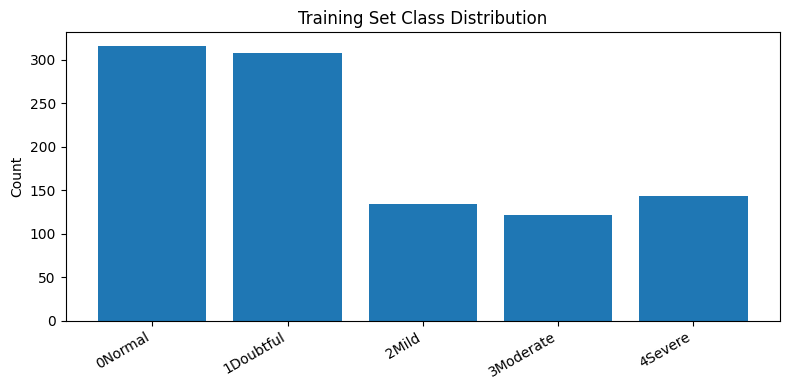

In [76]:
# Class weights from training distribution.
# These weights are used inside CrossEntropyLoss within the Hybrid Chen loss.

train_targets = np.array(train_raw.targets)
train_counts = np.bincount(train_targets, minlength=CONFIG["NUM_CLASSES"])

class_weights = train_counts.sum() / (CONFIG["NUM_CLASSES"] * train_counts)
class_weights = class_weights.astype(np.float32)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

class_weight_df = pd.DataFrame({
    "class_idx": list(range(CONFIG["NUM_CLASSES"])),
    "class_name": class_names,
    "train_count": train_counts,
    "class_weight": class_weights,
})

display(class_weight_df)

plt.figure(figsize=(8, 4))
plt.bar(class_weight_df["class_name"], class_weight_df["train_count"])
plt.title("Training Set Class Distribution")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [77]:
# Crop box utility and custom multi-region crop dataset.

CENTER_CROP_WIDTH_RATIO = 0.70
CENTER_CROP_HEIGHT_RATIO = 0.80
EDGE_CROP_WIDTH_RATIO = 0.55
EDGE_CROP_HEIGHT_RATIO = 0.80

LEFT_CENTER_X_RATIO = 0.30
RIGHT_CENTER_X_RATIO = 0.70
CENTER_X_RATIO = 0.50
CENTER_Y_RATIO = 0.50

def make_crop_box(width, height, center_x_ratio, center_y_ratio, width_ratio, height_ratio):
    crop_w = max(1, int(width * width_ratio))
    crop_h = max(1, int(height * height_ratio))

    cx = int(width * center_x_ratio)
    cy = int(height * center_y_ratio)

    left = cx - crop_w // 2
    top = cy - crop_h // 2

    left = max(0, min(left, width - crop_w))
    top = max(0, min(top, height - crop_h))
    right = left + crop_w
    bottom = top + crop_h

    return (left, top, right, bottom)

def crop_pil_image(img, crop_name):
    img = img.convert("RGB")
    w, h = img.size

    if crop_name == "wide":
        return img

    if crop_name == "center":
        box = make_crop_box(
            width=w,
            height=h,
            center_x_ratio=CENTER_X_RATIO,
            center_y_ratio=CENTER_Y_RATIO,
            width_ratio=CENTER_CROP_WIDTH_RATIO,
            height_ratio=CENTER_CROP_HEIGHT_RATIO,
        )
        return img.crop(box)

    if crop_name == "left_edge":
        box = make_crop_box(
            width=w,
            height=h,
            center_x_ratio=LEFT_CENTER_X_RATIO,
            center_y_ratio=CENTER_Y_RATIO,
            width_ratio=EDGE_CROP_WIDTH_RATIO,
            height_ratio=EDGE_CROP_HEIGHT_RATIO,
        )
        return img.crop(box)

    if crop_name == "right_edge":
        box = make_crop_box(
            width=w,
            height=h,
            center_x_ratio=RIGHT_CENTER_X_RATIO,
            center_y_ratio=CENTER_Y_RATIO,
            width_ratio=EDGE_CROP_WIDTH_RATIO,
            height_ratio=EDGE_CROP_HEIGHT_RATIO,
        )
        return img.crop(box)

    raise ValueError(f"Unknown crop name: {crop_name}")


class MultiRegionKneeDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, crop_names, image_size=224):
        self.base = datasets.ImageFolder(root_dir, transform=None)
        self.crop_names = crop_names
        self.image_size = image_size

        self.classes = self.base.classes
        self.class_to_idx = self.base.class_to_idx
        self.samples = self.base.samples
        self.targets = self.base.targets

        self.crop_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=normalize_mean, std=normalize_std),
        ])

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = self.base.loader(img_path).convert("RGB")

        crops = []
        for crop_name in self.crop_names:
            crop_img = crop_pil_image(img, crop_name)
            crop_tensor = self.crop_transform(crop_img)
            crops.append(crop_tensor)

        crops = torch.stack(crops, dim=0)  # [num_crops, 3, H, W]
        return crops, label


def build_loaders_for_crop_names(crop_names):
    train_dataset = MultiRegionKneeDataset(TRAIN_DIR, crop_names=crop_names, image_size=CONFIG["IMG_SIZE"])
    val_dataset = MultiRegionKneeDataset(VAL_DIR, crop_names=crop_names, image_size=CONFIG["IMG_SIZE"])
    test_dataset = MultiRegionKneeDataset(TEST_DIR, crop_names=crop_names, image_size=CONFIG["IMG_SIZE"])

    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    return train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset

print("MultiRegionKneeDataset is ready.")

MultiRegionKneeDataset is ready.


## 7. Visualization

This section shows:

1. original image  
2. transformed image  
3. CLAHE preview  
4. 4-crop example: wide / center / left edge / right edge

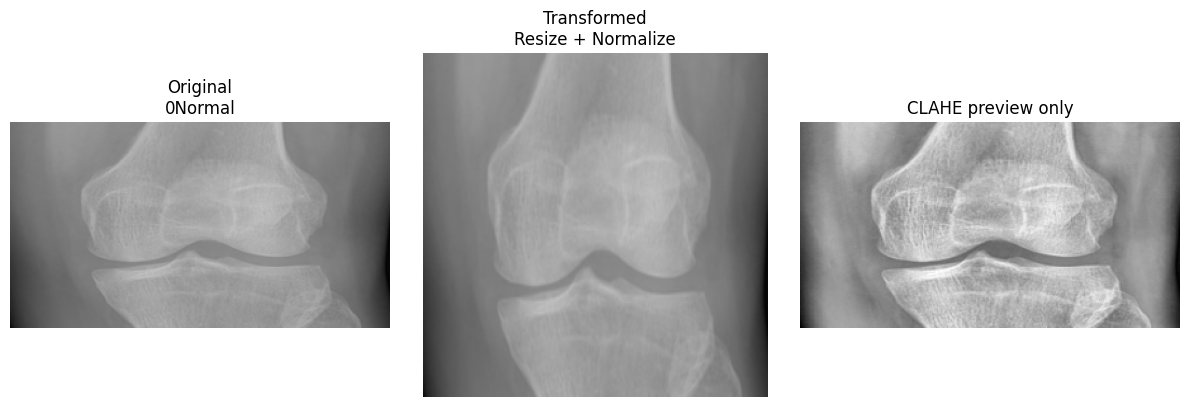

In [78]:
from PIL import Image

def apply_clahe_preview(pil_img):
    # CLAHE preview only. Not used during training.
    gray = np.array(pil_img.convert("L"))

    try:
        import cv2
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        return enhanced
    except Exception:
        # Fallback if cv2 is unavailable.
        from PIL import ImageOps
        return np.array(ImageOps.equalize(Image.fromarray(gray)))

# Pick one sample from the training set.
sample_path, sample_label = train_raw.samples[0]
sample_img = Image.open(sample_path).convert("RGB")
sample_tensor = single_image_transform(sample_img)
sample_transformed = denormalize_tensor(sample_tensor)
sample_clahe = apply_clahe_preview(sample_img)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_img, cmap="gray")
plt.title(f"Original\n{class_names[sample_label]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample_transformed)
plt.title("Transformed\nResize + Normalize")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sample_clahe, cmap="gray")
plt.title("CLAHE preview only")
plt.axis("off")

plt.tight_layout()
plt.show()

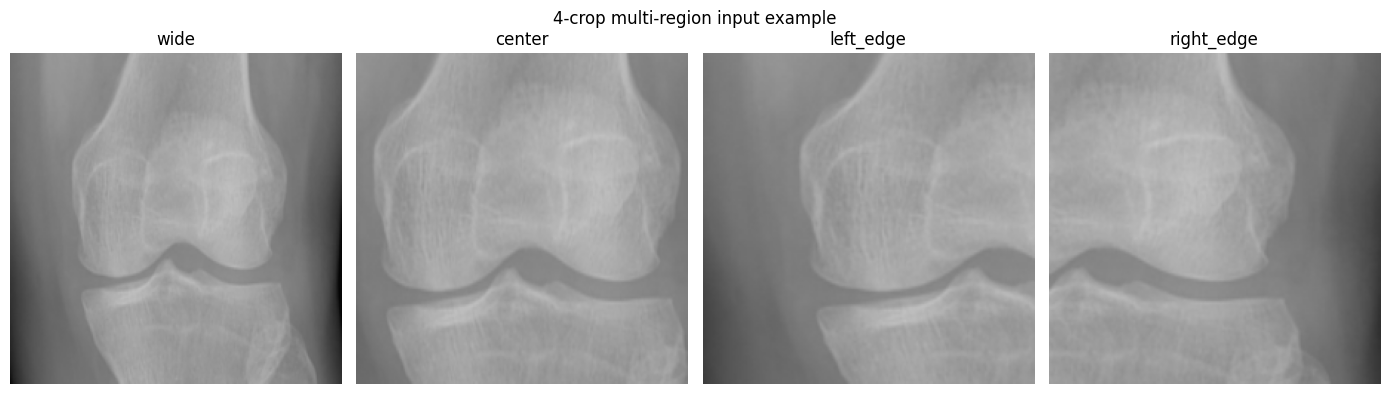

In [79]:
# Show the 4-crop example.
crop_names_example = ["wide", "center", "left_edge", "right_edge"]

plt.figure(figsize=(14, 4))
for i, crop_name in enumerate(crop_names_example, start=1):
    crop_img = crop_pil_image(sample_img, crop_name)
    crop_tensor = transforms.Compose([
        transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
        transforms.ToTensor(),
        transforms.Normalize(mean=normalize_mean, std=normalize_std),
    ])(crop_img)

    plt.subplot(1, 4, i)
    plt.imshow(denormalize_tensor(crop_tensor))
    plt.title(crop_name)
    plt.axis("off")

plt.suptitle("4-crop multi-region input example")
plt.tight_layout()
plt.show()

## 8. Model Definition

The model uses DenseNet121 as the shared feature extractor.

For each X-ray image, the input shape is:

```text
[B, num_crops, 3, H, W]
```

Each crop is passed through the same DenseNet121 backbone.  
The crop features are then averaged before classification.

This allows a clean comparison between:

- single full image
- center crop only
- wide + center
- wide + center + left + right

In [80]:
class MultiRegionDenseNet121(nn.Module):
    def __init__(self, num_classes=5, dropout=0.3):
        super().__init__()

        try:
            weights = models.DenseNet121_Weights.DEFAULT
            backbone = models.densenet121(weights=weights)
        except Exception:
            backbone = models.densenet121(pretrained=True)

        self.features = backbone.features
        feature_dim = backbone.classifier.in_features

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, num_classes),
        )

    def extract_features(self, x):
        # x: [B, 3, H, W]
        feats = self.features(x)
        feats = torch.relu(feats)
        feats = torch.nn.functional.adaptive_avg_pool2d(feats, (1, 1))
        feats = torch.flatten(feats, 1)
        return feats

    def forward(self, crops):
        # crops: [B, N, 3, H, W]
        if crops.dim() == 4:
            crops = crops.unsqueeze(1)

        b, n, c, h, w = crops.shape
        crops_flat = crops.view(b * n, c, h, w)

        crop_features = self.extract_features(crops_flat)
        crop_features = crop_features.view(b, n, -1)

        fused_features = crop_features.mean(dim=1)
        logits = self.classifier(fused_features)

        return logits

def build_model():
    model = MultiRegionDenseNet121(
        num_classes=CONFIG["NUM_CLASSES"],
        dropout=CONFIG["DROPOUT"],
    )
    return model.to(device)

model_check = build_model()
dummy = torch.randn(2, 4, 3, CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]).to(device)
with torch.no_grad():
    out = model_check(dummy)
print("Dummy output shape:", out.shape)
del model_check, dummy, out
torch.cuda.empty_cache()

Dummy output shape: torch.Size([2, 5])


## 9. Loss Function

The selected loss from the previous experiment is **Class-weighted HybridChenOrdinalLoss**.

It combines:

```text
CrossEntropyLoss with class weights
+
alpha × Chen-style ordinal penalty
```

This is used because knee OA grading is ordinal:

```text
0Normal < 1Doubtful < 2Mild < 3Moderate < 4Severe
```

The class-weighted CE part handles training set imbalance, while the Chen ordinal penalty discourages severe grading errors.

In [81]:
class ClassWeightedHybridChenOrdinalLoss(nn.Module):
    def __init__(
        self,
        num_classes=5,
        class_weights=None,
        alpha=0.10,
        penalty_distance=2,
        square_loss=False,
        normalize=True,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.alpha = alpha
        self.penalty_distance = penalty_distance
        self.square_loss = square_loss
        self.normalize = normalize

        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights)

        penalty_matrix = self._create_penalty_matrix(
            num_classes=num_classes,
            penalty_distance=penalty_distance,
            normalize=normalize,
        )

        self.register_buffer("penalty_matrix", penalty_matrix)

    def _create_penalty_matrix(self, num_classes, penalty_distance, normalize):
        class_indices = torch.arange(num_classes, dtype=torch.float32)

        distance_matrix = torch.abs(
            class_indices.unsqueeze(0) - class_indices.unsqueeze(1)
        )

        penalty_matrix = distance_matrix * penalty_distance + 1.0
        penalty_matrix[distance_matrix == 0] = 0.0

        if normalize:
            max_value = penalty_matrix.max()
            if max_value > 0:
                penalty_matrix = penalty_matrix / max_value

        return penalty_matrix

    def forward(self, logits, targets, return_parts=False):
        ce = self.ce_loss(logits, targets)

        probabilities = torch.softmax(logits, dim=1)
        penalty_matrix = self.penalty_matrix.to(logits.device)
        target_penalties = penalty_matrix[targets.long()]

        penalty_per_sample = torch.sum(
            probabilities * target_penalties,
            dim=1
        )

        if self.square_loss:
            penalty_per_sample = penalty_per_sample ** 2

        ordinal_penalty = torch.mean(penalty_per_sample)
        total_loss = ce + self.alpha * ordinal_penalty

        if return_parts:
            return total_loss, ce, ordinal_penalty, self.alpha * ordinal_penalty

        return total_loss

criterion_check = ClassWeightedHybridChenOrdinalLoss(
    num_classes=CONFIG["NUM_CLASSES"],
    class_weights=class_weights_tensor,
    alpha=CONFIG["ORDINAL_ALPHA"],
    penalty_distance=CONFIG["PENALTY_DISTANCE"],
    square_loss=CONFIG["SQUARE_LOSS"],
    normalize=CONFIG["NORMALIZE_MATRIX"],
).to(device)

print("Class weights:")
print(class_weights_tensor.detach().cpu().numpy())

print("\nHybrid Chen penalty matrix:")
print(criterion_check.penalty_matrix.detach().cpu().numpy())

print("\nLoss formula:")
print("total_loss = class_weighted_CE + alpha * chen_ordinal_penalty")
print("alpha =", CONFIG["ORDINAL_ALPHA"])

Class weights:
[0.6481013  0.66493505 1.5283582  1.6786885  1.4222223 ]

Hybrid Chen penalty matrix:
[[0.         0.33333334 0.5555556  0.7777778  1.        ]
 [0.33333334 0.         0.33333334 0.5555556  0.7777778 ]
 [0.5555556  0.33333334 0.         0.33333334 0.5555556 ]
 [0.7777778  0.5555556  0.33333334 0.         0.33333334]
 [1.         0.7777778  0.5555556  0.33333334 0.        ]]

Loss formula:
total_loss = class_weighted_CE + alpha * chen_ordinal_penalty
alpha = 0.1


## 10. Optimizer & Scheduler

Each crop strategy uses the same optimizer and scheduler for fair comparison.

In [82]:
def build_optimizer_and_scheduler(model):
    optimizer = torch.optim.AdamW(
       model.parameters(),
       lr=CONFIG["LR"],
       weight_decay=CONFIG["WEIGHT_DECAY"],
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["EPOCHS"],
    )

    return optimizer, scheduler

print("Optimizer: AdamW")
print("Scheduler: CosineAnnealingLR")

Optimizer: AdamW
Scheduler: CosineAnnealingLR


## 11. Training Loop

The loop records:

- train loss
- validation loss
- validation accuracy
- validation macro F1
- validation QWK
- validation MAE

The best checkpoint is selected using validation QWK.

In [83]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    mae = float(np.mean(np.abs(y_true - y_pred)))

    diff = np.abs(y_true - y_pred)
    adjacent_errors = int(np.sum(diff == 1))
    distant_errors = int(np.sum(diff >= 2))
    total_errors = int(np.sum(diff > 0))

    return {
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "qwk": float(qwk),
        "mae": float(mae),
        "total_errors": total_errors,
        "adjacent_errors": adjacent_errors,
        "distant_errors": distant_errors,
    }


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    running_ce = 0.0
    running_ord = 0.0

    y_true = []
    y_pred = []

    for crops, labels in loader:
        crops = crops.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(crops)
        loss, ce_loss, ordinal_loss, weighted_ordinal_loss = criterion(
            logits,
            labels,
            return_parts=True,
        )

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_ce += ce_loss.item() * batch_size
        running_ord += ordinal_loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = running_loss / len(loader.dataset)
    metrics["ce_loss"] = running_ce / len(loader.dataset)
    metrics["ordinal_loss"] = running_ord / len(loader.dataset)

    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    y_true = []
    y_pred = []

    for crops, labels in loader:
        crops = crops.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(crops)
        loss = criterion(logits, labels)

        preds = torch.argmax(logits, dim=1)

        running_loss += loss.item() * labels.size(0)
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = running_loss / len(loader.dataset)

    return metrics, y_true, y_pred


def train_crop_experiment(exp_config):
    exp_name = exp_config["name"]
    crop_names = exp_config["crop_names"]

    print("=" * 80)
    print("Running experiment:", exp_name)
    print("Crops:", crop_names)
    print(exp_config["description"])

    set_seed(CONFIG["SEED"])

    train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = build_loaders_for_crop_names(crop_names)

    model = build_model()

    criterion = ClassWeightedHybridChenOrdinalLoss(
        num_classes=CONFIG["NUM_CLASSES"],
        class_weights=class_weights_tensor,
        alpha=CONFIG["ORDINAL_ALPHA"],
        penalty_distance=CONFIG["PENALTY_DISTANCE"],
        square_loss=CONFIG["SQUARE_LOSS"],
        normalize=CONFIG["NORMALIZE_MATRIX"],
    ).to(device)

    optimizer, scheduler = build_optimizer_and_scheduler(model)

    best_val_qwk = -999
    best_epoch = -1
    best_model_path = MODELS_DIR / f"{exp_name}_best.pth"
    history = []
    patience_counter = 0

    for epoch in range(1, CONFIG["EPOCHS"] + 1):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics, _, _ = evaluate(model, val_loader, criterion)

        scheduler.step()

        row = {
            "experiment": exp_name,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_ce_loss": train_metrics["ce_loss"],
            "train_ordinal_loss": train_metrics["ordinal_loss"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_qwk": val_metrics["qwk"],
            "val_mae": val_metrics["mae"],
            "val_adjacent_errors": val_metrics["adjacent_errors"],
            "val_distant_errors": val_metrics["distant_errors"],
        }

        history.append(row)

        print(
            f"Epoch {epoch:02d}/{CONFIG['EPOCHS']} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_qwk={val_metrics['qwk']:.4f} | "
            f"val_mae={val_metrics['mae']:.4f}"
        )

        if val_metrics["qwk"] > best_val_qwk:
            best_val_qwk = val_metrics["qwk"]
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print("  Saved new best checkpoint.")
        else:
            patience_counter += 1

        if patience_counter >= CONFIG["PATIENCE"]:
            print("Early stopping triggered.")
            break

    history_df = pd.DataFrame(history)
    history_path = RESULTS_DIR / f"{exp_name}_history.csv"
    history_df.to_csv(history_path, index=False)

    # Load best model for test evaluation.
    model.load_state_dict(torch.load(best_model_path, map_location=device))

    test_metrics, test_true, test_pred = evaluate(model, test_loader, criterion)
    test_metrics["best_val_qwk"] = float(best_val_qwk)
    test_metrics["best_epoch"] = int(best_epoch)
    test_metrics["experiment"] = exp_name
    test_metrics["crop_names"] = crop_names
    test_metrics["num_crops"] = len(crop_names)
    test_metrics["model_path"] = str(best_model_path)
    test_metrics["history_path"] = str(history_path)

    print("\nTest results for:", exp_name)
    for k, v in test_metrics.items():
        if isinstance(v, (int, float)):
            print(f"{k}: {v}")

    # Save predictions for later analysis.
    pred_df = pd.DataFrame({
        "y_true": test_true,
        "y_pred": test_pred,
        "true_class": [class_names[i] for i in test_true],
        "pred_class": [class_names[i] for i in test_pred],
        "error_distance": np.abs(np.array(test_true) - np.array(test_pred)),
    })
    pred_path = RESULTS_DIR / f"{exp_name}_test_predictions.csv"
    pred_df.to_csv(pred_path, index=False)

    # Save confusion matrix figure.
    cm = confusion_matrix(test_true, test_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm)
    ax.set_title(f"Confusion Matrix: {exp_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    cm_path = FIGURES_DIR / f"{exp_name}_confusion_matrix.png"
    fig.savefig(cm_path, dpi=200, bbox_inches="tight")
    plt.show()

    test_metrics["predictions_path"] = str(pred_path)
    test_metrics["confusion_matrix_path"] = str(cm_path)

    del model
    torch.cuda.empty_cache()

    return test_metrics, history_df, test_true, test_pred

Running experiment: single_wide
Crops: ['wide']
Single full X-ray image only.
Epoch 01/30 | train_loss=1.2611 | val_loss=0.8562 | val_acc=0.6986 | val_qwk=0.8244 | val_mae=0.4315
  Saved new best checkpoint.
Epoch 02/30 | train_loss=0.7441 | val_loss=0.7349 | val_acc=0.7260 | val_qwk=0.8602 | val_mae=0.3493
  Saved new best checkpoint.
Epoch 03/30 | train_loss=0.3815 | val_loss=0.6302 | val_acc=0.8014 | val_qwk=0.8918 | val_mae=0.2603
  Saved new best checkpoint.
Epoch 04/30 | train_loss=0.2407 | val_loss=0.7063 | val_acc=0.7466 | val_qwk=0.8560 | val_mae=0.3425
Epoch 05/30 | train_loss=0.1522 | val_loss=0.6853 | val_acc=0.7877 | val_qwk=0.8814 | val_mae=0.2808
Epoch 06/30 | train_loss=0.1187 | val_loss=0.6890 | val_acc=0.7740 | val_qwk=0.8850 | val_mae=0.2877
Epoch 07/30 | train_loss=0.1063 | val_loss=0.6465 | val_acc=0.8151 | val_qwk=0.8936 | val_mae=0.2466
  Saved new best checkpoint.
Epoch 08/30 | train_loss=0.0822 | val_loss=0.9899 | val_acc=0.7466 | val_qwk=0.8940 | val_mae=0.301

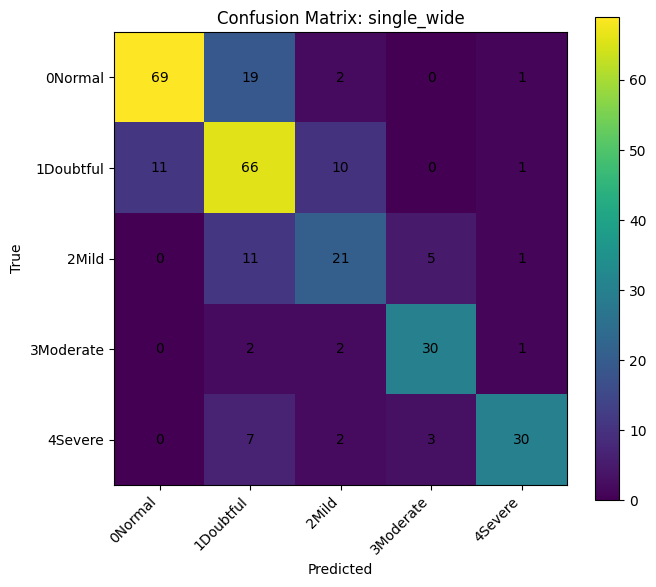

Running experiment: center_only
Crops: ['center']
Central joint-space crop only.
Epoch 01/30 | train_loss=1.2476 | val_loss=0.8105 | val_acc=0.7192 | val_qwk=0.8659 | val_mae=0.3562
  Saved new best checkpoint.
Epoch 02/30 | train_loss=0.7019 | val_loss=0.7274 | val_acc=0.7192 | val_qwk=0.8450 | val_mae=0.3767
Epoch 03/30 | train_loss=0.3617 | val_loss=0.5877 | val_acc=0.7808 | val_qwk=0.9021 | val_mae=0.2740
  Saved new best checkpoint.
Epoch 04/30 | train_loss=0.2505 | val_loss=0.6521 | val_acc=0.7397 | val_qwk=0.8868 | val_mae=0.3151
Epoch 05/30 | train_loss=0.1702 | val_loss=0.7485 | val_acc=0.7055 | val_qwk=0.8373 | val_mae=0.4041
Epoch 06/30 | train_loss=0.1443 | val_loss=0.6600 | val_acc=0.7808 | val_qwk=0.8756 | val_mae=0.3014
Epoch 07/30 | train_loss=0.1400 | val_loss=0.7687 | val_acc=0.7603 | val_qwk=0.8783 | val_mae=0.3151
Epoch 08/30 | train_loss=0.1216 | val_loss=0.8126 | val_acc=0.7329 | val_qwk=0.8360 | val_mae=0.3767
Epoch 09/30 | train_loss=0.0929 | val_loss=0.6253 | v

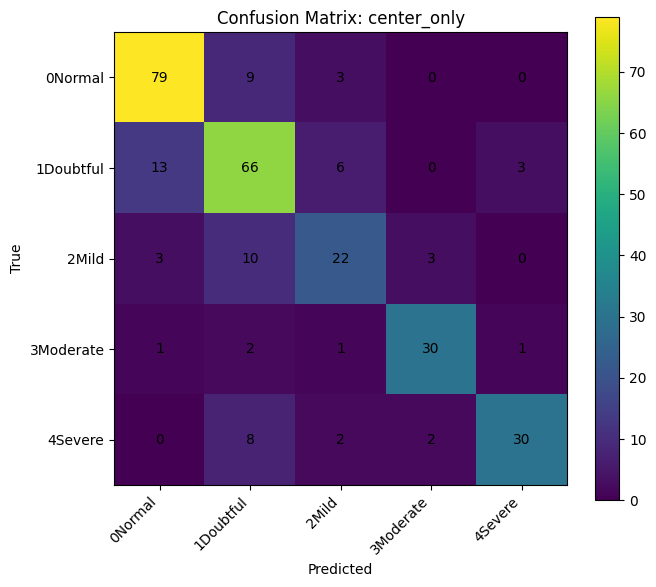

Running experiment: wide_center_2crop
Crops: ['wide', 'center']
Full image plus central joint-space crop.
Epoch 01/30 | train_loss=1.2052 | val_loss=0.7750 | val_acc=0.6986 | val_qwk=0.8354 | val_mae=0.4041
  Saved new best checkpoint.
Epoch 02/30 | train_loss=0.6994 | val_loss=0.7448 | val_acc=0.6918 | val_qwk=0.8439 | val_mae=0.3904
  Saved new best checkpoint.
Epoch 03/30 | train_loss=0.3674 | val_loss=0.5644 | val_acc=0.8014 | val_qwk=0.8884 | val_mae=0.2671
  Saved new best checkpoint.
Epoch 04/30 | train_loss=0.2667 | val_loss=0.6850 | val_acc=0.7534 | val_qwk=0.8637 | val_mae=0.3356
Epoch 05/30 | train_loss=0.1669 | val_loss=0.6119 | val_acc=0.7945 | val_qwk=0.9009 | val_mae=0.2534
  Saved new best checkpoint.
Epoch 06/30 | train_loss=0.1268 | val_loss=0.7758 | val_acc=0.7329 | val_qwk=0.8745 | val_mae=0.3288
Epoch 07/30 | train_loss=0.1331 | val_loss=0.8459 | val_acc=0.6918 | val_qwk=0.8355 | val_mae=0.4247
Epoch 08/30 | train_loss=0.1194 | val_loss=1.0249 | val_acc=0.7055 | va

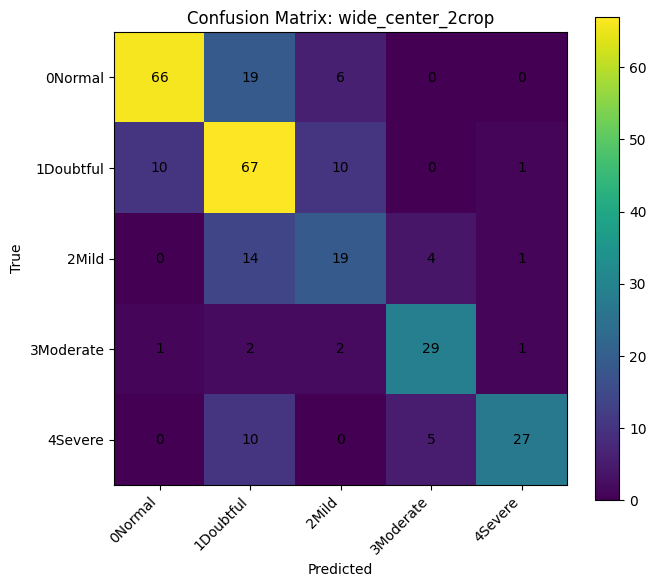

Running experiment: wide_center_edges_4crop
Crops: ['wide', 'center', 'left_edge', 'right_edge']
Full image, central joint space, left edge, and right edge.
Epoch 01/30 | train_loss=1.1815 | val_loss=0.7431 | val_acc=0.7534 | val_qwk=0.8811 | val_mae=0.3151
  Saved new best checkpoint.
Epoch 02/30 | train_loss=0.7099 | val_loss=0.9378 | val_acc=0.6164 | val_qwk=0.7755 | val_mae=0.5342
Epoch 03/30 | train_loss=0.3988 | val_loss=0.6149 | val_acc=0.7740 | val_qwk=0.8848 | val_mae=0.2945
  Saved new best checkpoint.
Epoch 04/30 | train_loss=0.2820 | val_loss=0.6964 | val_acc=0.7397 | val_qwk=0.8529 | val_mae=0.3493
Epoch 05/30 | train_loss=0.1798 | val_loss=0.5869 | val_acc=0.8151 | val_qwk=0.9028 | val_mae=0.2397
  Saved new best checkpoint.
Epoch 06/30 | train_loss=0.1387 | val_loss=0.6380 | val_acc=0.8151 | val_qwk=0.9104 | val_mae=0.2329
  Saved new best checkpoint.
Epoch 07/30 | train_loss=0.1313 | val_loss=0.7923 | val_acc=0.7397 | val_qwk=0.8397 | val_mae=0.3699
Epoch 08/30 | train_

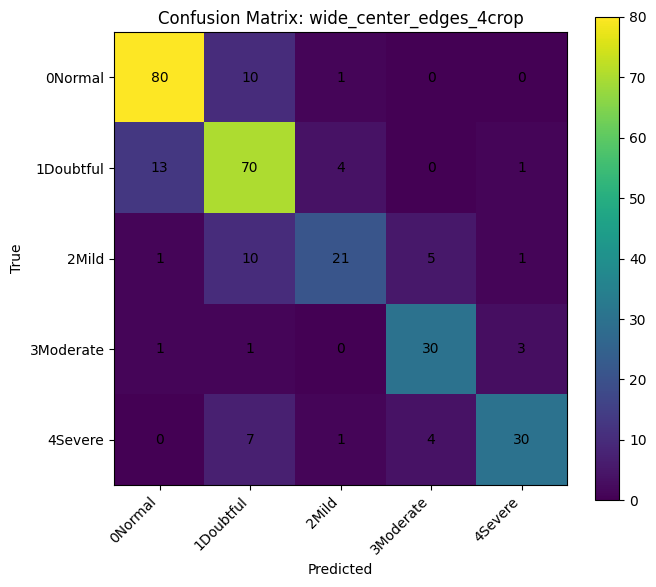

,accuracy,macro_f1,weighted_f1,qwk,mae,total_errors,adjacent_errors,distant_errors,loss,best_val_qwk,best_epoch,experiment,crop_names,num_crops,model_path,history_path,predictions_path,confusion_matrix_path
3,0.785714,0.769818,0.782910,0.867037,0.292517,63,49,14,0.847683,0.931571,22,wide_center_edges_4crop,"[wide, center, left_edge, right_edge]",4,/kaggle/working/exp04_crop_comparison_classwei...,/kaggle/working/exp04_crop_comparison_classwei...,/kaggle/working/exp04_crop_comparison_classwei...,/kaggle/working/exp04_crop_comparison_classwei...
0,0.734694,0.732469,0.737517,0.836798,0.353741,78,62,16,0.789244,0.917644,10,single_wide,[wide],1,/kaggle/working/exp04_crop_comparison_classwei...,/kaggle/working/exp04_crop_comparison_classwei...,/kaggle/working/exp04_crop_comparison_classwei...,/kaggle/working/exp04_crop_comparison_classwei...
1,0.772109,0.764792,0.771235,0.827060,0.343537,67,45,22,0.611235,0.902104,3,center_only,[center],1,/kaggle/working/exp04_crop_comparison_classwei...,/kaggle/working/exp04_crop_comparison_classwei...,/kaggle/working/exp04_crop_comparison_classwei...,/kaggle/working/exp04_crop_comparison_classwei...
2,0.707483,0.701380,0.710958,0.802910,0.404762,86,65,21,0.794883,0.900901,5,wide_center_2crop,"[wide, center]",2,/kaggle/working/exp04_crop_comparison_classwei...,/kaggle/working/exp04_crop_comparison_classwei...,/kaggle/working/exp04_crop_comparison_classwei...,/kaggle/working/exp04_crop_comparison_classwei...


Saved comparison results to: /kaggle/working/exp04_crop_comparison_classweighted_hybridchen/results/crop_comparison_results.csv


In [84]:
all_results = []
all_histories = {}
last_test_true = None
last_test_pred = None

for exp in CROP_EXPERIMENTS:
    if exp["name"] not in RUN_EXPERIMENT_NAMES:
        continue

    metrics, history_df, test_true, test_pred = train_crop_experiment(exp)

    all_results.append(metrics)
    all_histories[metrics["experiment"]] = history_df

    last_test_true = test_true
    last_test_pred = test_pred

results_df = pd.DataFrame(all_results)
display(results_df.sort_values("qwk", ascending=False))

results_csv_path = RESULTS_DIR / "crop_comparison_results.csv"
results_df.to_csv(results_csv_path, index=False)

print("Saved comparison results to:", results_csv_path)

## 12. Validation Section

The model was selected based on validation QWK.  
The table below summarizes the best validation performance for each crop strategy.

,experiment,epoch,val_accuracy,val_macro_f1,val_qwk,val_mae,val_adjacent_errors,val_distant_errors
3,wide_center_edges_4crop,22,0.842466,0.822789,0.931571,0.191781,19,4
0,single_wide,10,0.815068,0.778802,0.917644,0.219178,24,3
1,center_only,3,0.780822,0.758143,0.902104,0.273973,25,7
2,wide_center_2crop,5,0.794521,0.788925,0.900901,0.253425,25,5


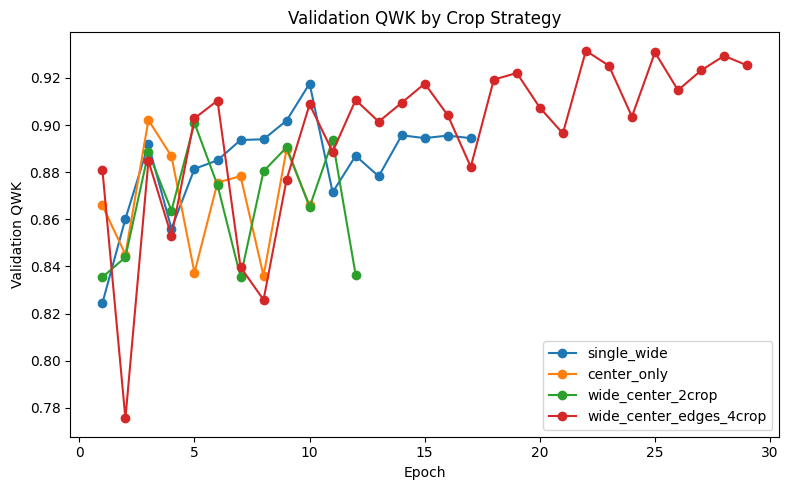

In [85]:
val_summary_rows = []

for exp_name, hist in all_histories.items():
    best_idx = hist["val_qwk"].idxmax()
    best_row = hist.loc[best_idx].to_dict()
    val_summary_rows.append(best_row)

val_summary_df = pd.DataFrame(val_summary_rows)
display(val_summary_df[[
    "experiment",
    "epoch",
    "val_accuracy",
    "val_macro_f1",
    "val_qwk",
    "val_mae",
    "val_adjacent_errors",
    "val_distant_errors",
]].sort_values("val_qwk", ascending=False))

plt.figure(figsize=(8, 5))
for exp_name, hist in all_histories.items():
    plt.plot(hist["epoch"], hist["val_qwk"], marker="o", label=exp_name)

plt.xlabel("Epoch")
plt.ylabel("Validation QWK")
plt.title("Validation QWK by Crop Strategy")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Test Evaluation

This section compares the final test performance across crop strategies.

In [86]:
test_comparison_cols = [
    "experiment",
    "num_crops",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "qwk",
    "mae",
    "total_errors",
    "adjacent_errors",
    "distant_errors",
    "best_val_qwk",
    "best_epoch",
]

display(results_df[test_comparison_cols].sort_values("qwk", ascending=False))

best_result = results_df.sort_values("qwk", ascending=False).iloc[0].to_dict()
BEST_EXPERIMENT_NAME = best_result["experiment"]

print("Best crop experiment by test QWK:", BEST_EXPERIMENT_NAME)
print("Best test QWK:", best_result["qwk"])
print("Best test MAE:", best_result["mae"])
print("Best test accuracy:", best_result["accuracy"])

,experiment,num_crops,accuracy,macro_f1,weighted_f1,qwk,mae,total_errors,adjacent_errors,distant_errors,best_val_qwk,best_epoch
3,wide_center_edges_4crop,4,0.785714,0.769818,0.782910,0.867037,0.292517,63,49,14,0.931571,22
0,single_wide,1,0.734694,0.732469,0.737517,0.836798,0.353741,78,62,16,0.917644,10
1,center_only,1,0.772109,0.764792,0.771235,0.827060,0.343537,67,45,22,0.902104,3
2,wide_center_2crop,2,0.707483,0.701380,0.710958,0.802910,0.404762,86,65,21,0.900901,5


Best crop experiment by test QWK: wide_center_edges_4crop
Best test QWK: 0.8670365121958573
Best test MAE: 0.2925170068027211
Best test accuracy: 0.7857142857142857


## 13.1 Per-class Recall and F1

Class-wise recall and F1 are reported for the best crop strategy.

In [87]:
# Load best predictions.
best_pred_path = Path(best_result["predictions_path"])
best_pred_df = pd.read_csv(best_pred_path)

best_true = best_pred_df["y_true"].values
best_pred = best_pred_df["y_pred"].values

report_dict = classification_report(
    best_true,
    best_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

classwise_rows = []
for class_name in class_names:
    classwise_rows.append({
        "class_name": class_name,
        "precision": report_dict[class_name]["precision"],
        "recall": report_dict[class_name]["recall"],
        "f1_score": report_dict[class_name]["f1-score"],
        "support": report_dict[class_name]["support"],
    })

classwise_df = pd.DataFrame(classwise_rows)
display(classwise_df)

classwise_path = RESULTS_DIR / f"{BEST_EXPERIMENT_NAME}_classwise_recall_f1.csv"
classwise_df.to_csv(classwise_path, index=False)
print("Saved class-wise metrics to:", classwise_path)

,class_name,precision,recall,f1_score,support
0,0Normal,0.842105,0.879121,0.860215,91.0
1,1Doubtful,0.714286,0.795455,0.752688,88.0
2,2Mild,0.777778,0.552632,0.646154,38.0
3,3Moderate,0.769231,0.857143,0.810811,35.0
4,4Severe,0.857143,0.714286,0.779221,42.0


Saved class-wise metrics to: /kaggle/working/exp04_crop_comparison_classweighted_hybridchen/results/wide_center_edges_4crop_classwise_recall_f1.csv


## 14. Confusion Matrix

The confusion matrix is shown for the best crop strategy.

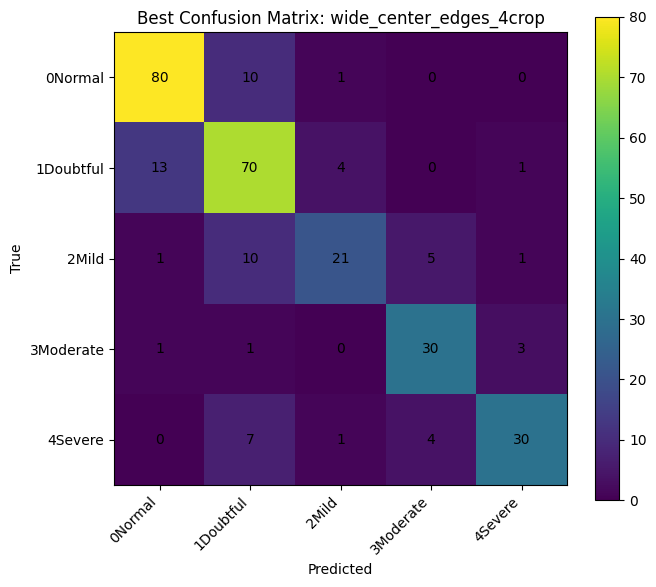

Saved best confusion matrix to: /kaggle/working/exp04_crop_comparison_classweighted_hybridchen/figures/best_confusion_matrix.png


In [88]:
cm = confusion_matrix(best_true, best_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm)
ax.set_title(f"Best Confusion Matrix: {BEST_EXPERIMENT_NAME}")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.tight_layout()

best_cm_path = FIGURES_DIR / "best_confusion_matrix.png"
fig.savefig(best_cm_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved best confusion matrix to:", best_cm_path)

## 15. Error Analysis

For ordinal classification, adjacent and distant errors are important.

- **Adjacent error:** prediction differs by 1 grade
- **Distant error:** prediction differs by 2 or more grades

Reducing distant grading errors is especially important for medical decision support.

In [89]:
error_summary_rows = []

for _, row in results_df.iterrows():
    pred_df = pd.read_csv(row["predictions_path"])
    diff = np.abs(pred_df["y_true"].values - pred_df["y_pred"].values)

    error_summary_rows.append({
        "experiment": row["experiment"],
        "total_errors": int(np.sum(diff > 0)),
        "adjacent_errors": int(np.sum(diff == 1)),
        "distant_errors": int(np.sum(diff >= 2)),
        "mean_error_distance": float(np.mean(diff)),
        "max_error_distance": int(np.max(diff)),
    })

error_summary_df = pd.DataFrame(error_summary_rows)
display(error_summary_df.sort_values("distant_errors"))

error_summary_path = RESULTS_DIR / "crop_error_analysis_summary.csv"
error_summary_df.to_csv(error_summary_path, index=False)
print("Saved error analysis summary to:", error_summary_path)

,experiment,total_errors,adjacent_errors,distant_errors,mean_error_distance,max_error_distance
3,wide_center_edges_4crop,63,49,14,0.292517,3
0,single_wide,78,62,16,0.353741,4
2,wide_center_2crop,86,65,21,0.404762,3
1,center_only,67,45,22,0.343537,3


Saved error analysis summary to: /kaggle/working/exp04_crop_comparison_classweighted_hybridchen/results/crop_error_analysis_summary.csv


Wrong samples for wide_center_edges_4crop: 63 / 294


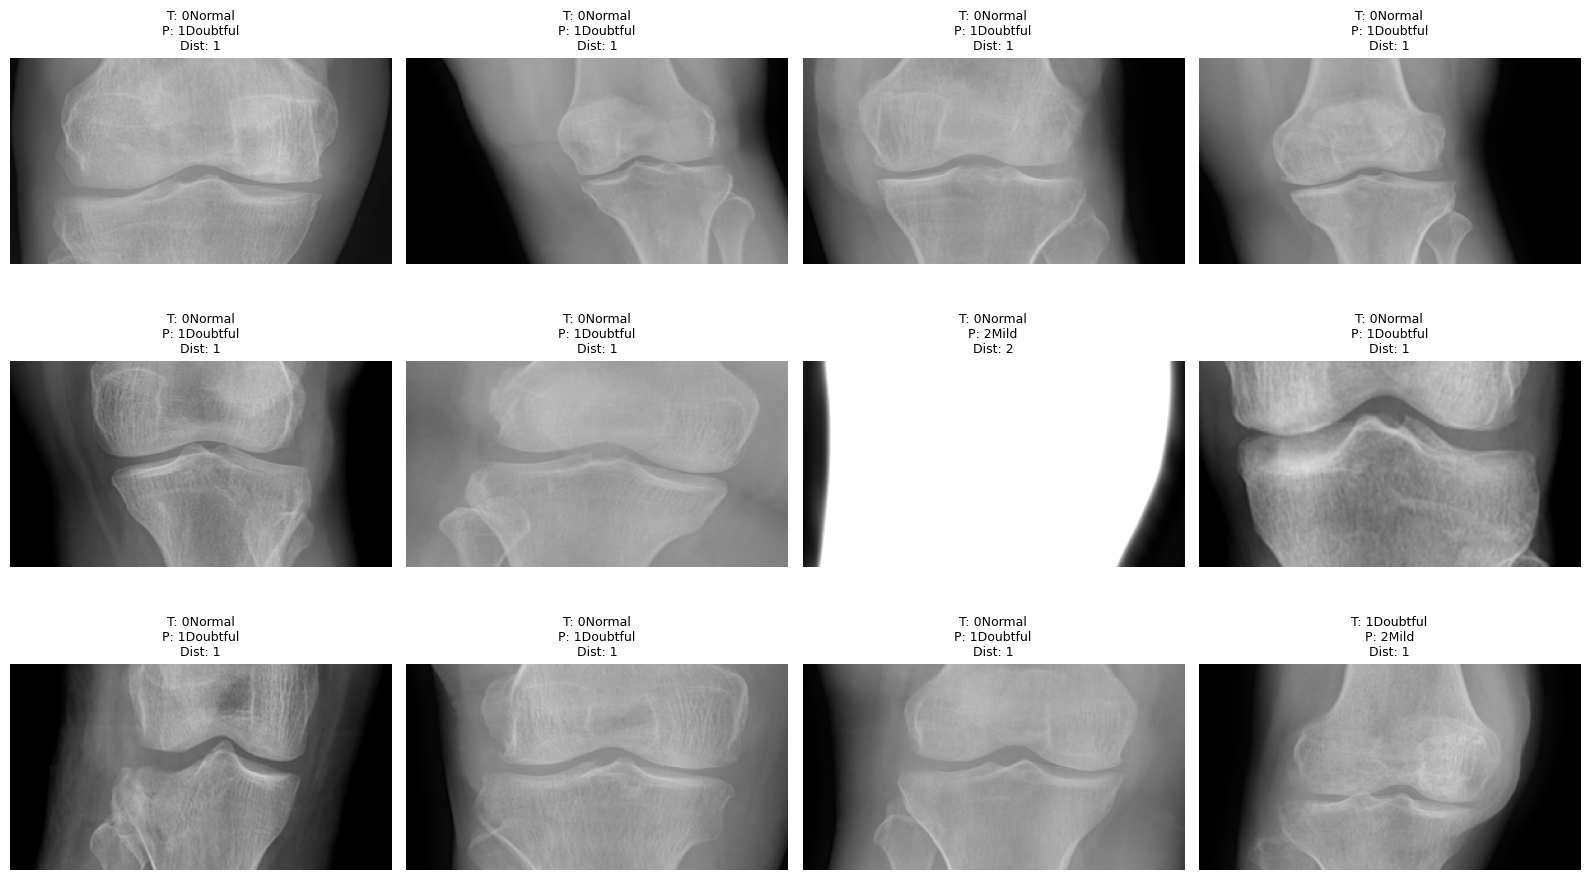

In [90]:
# Display a few misclassified raw images from the best crop strategy.
from PIL import Image

wrong_indices = best_pred_df.index[best_pred_df["y_true"] != best_pred_df["y_pred"]].tolist()
print(f"Wrong samples for {BEST_EXPERIMENT_NAME}: {len(wrong_indices)} / {len(best_pred_df)}")

show_indices = wrong_indices[:12]
cols = 4
rows = math.ceil(len(show_indices) / cols) if len(show_indices) > 0 else 1

plt.figure(figsize=(cols * 4, rows * 3.2))

raw_test_dataset = datasets.ImageFolder(TEST_DIR, transform=None)

for plot_i, idx in enumerate(show_indices, start=1):
    img_path, true_label = raw_test_dataset.samples[idx]
    pred_label = int(best_pred_df.loc[idx, "y_pred"])
    dist = abs(int(true_label) - pred_label)

    img = Image.open(img_path).convert("L")

    plt.subplot(rows, cols, plot_i)
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.axis("off")
    plt.title(
        f"T: {class_names[int(true_label)]}\n"
        f"P: {class_names[pred_label]}\n"
        f"Dist: {dist}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 16. Grad-CAM

Grad-CAM is generated for the best crop strategy.

For a multi-crop model, Grad-CAM is displayed on one selected crop.  
By default, this notebook shows the `center` crop if it exists; otherwise, it shows the first crop.

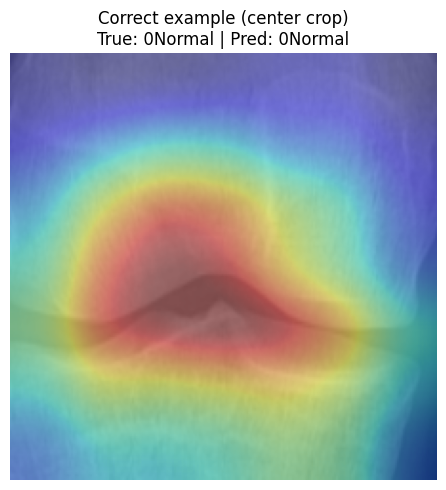

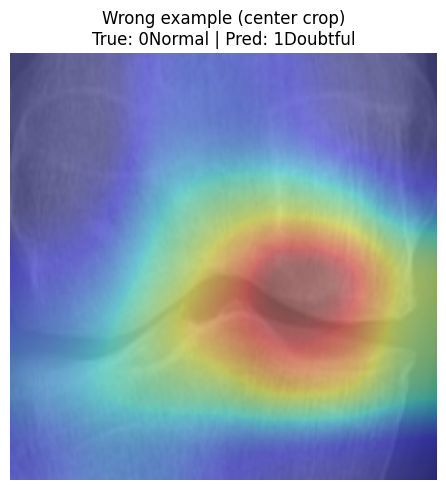

In [91]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd_handle = target_layer.register_forward_hook(self._forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def generate(self, crops, target_class=None, crop_idx=0):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        crops = crops.unsqueeze(0).to(device)  # [1, N, 3, H, W]

        logits = self.model(crops)

        if target_class is None:
            target_class = int(torch.argmax(logits, dim=1).item())

        score = logits[0, target_class]
        score.backward()

        activations = self.activations
        gradients = self.gradients

        # Since batch size is 1, flattened crop index equals crop_idx.
        act = activations[crop_idx]
        grad = gradients[crop_idx]

        weights = grad.mean(dim=(1, 2), keepdim=True)
        cam = torch.sum(weights * act, dim=0)

        cam = torch.relu(cam)
        cam = cam.detach().cpu().numpy()

        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = np.zeros_like(cam)

        return cam, target_class


def show_gradcam_for_index(model, dataset, idx, crop_idx=0, title_prefix="Grad-CAM"):
    crops, label = dataset[idx]

    model.eval()
    with torch.no_grad():
        logits = model(crops.unsqueeze(0).to(device))
        pred = int(torch.argmax(logits, dim=1).item())

    target_layer = model.features.denseblock4
    gradcam = GradCAM(model, target_layer)

    cam, target_class = gradcam.generate(crops, target_class=pred, crop_idx=crop_idx)
    gradcam.remove()

    crop_img = denormalize_tensor(crops[crop_idx])

    # Resize CAM to image size using PIL.
    cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize(
        (CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])
    )
    cam_resized = np.array(cam_img) / 255.0

    plt.figure(figsize=(5, 5))
    plt.imshow(crop_img)
    plt.imshow(cam_resized, cmap="jet", alpha=0.4)
    plt.axis("off")
    plt.title(
        f"{title_prefix}\n"
        f"True: {class_names[int(label)]} | Pred: {class_names[pred]}"
    )
    plt.tight_layout()
    plt.show()


# Rebuild and load the best model.
best_crop_names = None
for exp in CROP_EXPERIMENTS:
    if exp["name"] == BEST_EXPERIMENT_NAME:
        best_crop_names = exp["crop_names"]
        break

best_test_dataset = MultiRegionKneeDataset(TEST_DIR, crop_names=best_crop_names, image_size=CONFIG["IMG_SIZE"])
best_model = build_model()
best_model.load_state_dict(torch.load(best_result["model_path"], map_location=device))
best_model.to(device)

# Prefer center crop for Grad-CAM if it exists.
if "center" in best_crop_names:
    selected_crop_idx = best_crop_names.index("center")
else:
    selected_crop_idx = 0

correct_indices = best_pred_df.index[best_pred_df["y_true"] == best_pred_df["y_pred"]].tolist()
wrong_indices = best_pred_df.index[best_pred_df["y_true"] != best_pred_df["y_pred"]].tolist()

if len(correct_indices) > 0:
    show_gradcam_for_index(
        best_model,
        best_test_dataset,
        correct_indices[0],
        crop_idx=selected_crop_idx,
        title_prefix=f"Correct example ({best_crop_names[selected_crop_idx]} crop)"
    )

if len(wrong_indices) > 0:
    show_gradcam_for_index(
        best_model,
        best_test_dataset,
        wrong_indices[0],
        crop_idx=selected_crop_idx,
        title_prefix=f"Wrong example ({best_crop_names[selected_crop_idx]} crop)"
    )

del best_model
torch.cuda.empty_cache()

## 17. Final Summary

# Experiment Conclusion

This experiment tested whether changing the input from a single full X-ray image to multiple anatomical regions improves knee OA grading.

The crop strategies compared were:

1. single wide image  
2. center crop only  
3. wide + center crop  
4. wide + center + left edge + right edge crop  

All strategies used the same DenseNet121 backbone and the same Class-weighted Hybrid Chen Ordinal Loss.

If the 4-crop strategy achieves higher QWK and/or lower MAE than the single-image setting, it suggests that multi-region anatomical information helps the model understand OA severity. If it does not improve, it still provides useful evidence that multi-crop input alone is not sufficient and may need to be combined with later improvements such as augmentation or hyperparameter tuning.

CLAHE is only previewed in this notebook and is not used for training, because previous experiments showed that CLAHE improvements were unstable across runs.

In [92]:
summary = {
    "experiment_group": "crop_input_comparison",
    "selected_loss": CONFIG["LOSS"],
    "selected_imbalance_method": "class_weighted_loss",
    "best_experiment": BEST_EXPERIMENT_NAME,
    "best_metrics": {
        k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v)
        for k, v in best_result.items()
        if k in [
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "qwk",
            "mae",
            "total_errors",
            "adjacent_errors",
            "distant_errors",
            "best_val_qwk",
            "best_epoch",
        ]
    },
    "crop_experiments": CROP_EXPERIMENTS,
}

print(json.dumps(summary, indent=2))

{
  "experiment_group": "crop_input_comparison",
  "selected_loss": "ClassWeightedHybridChenOrdinalLoss",
  "selected_imbalance_method": "class_weighted_loss",
  "best_experiment": "wide_center_edges_4crop",
  "best_metrics": {
    "accuracy": 0.7857142857142857,
    "macro_f1": 0.7698177323983776,
    "weighted_f1": 0.7829102935093718,
    "qwk": 0.8670365121958573,
    "mae": 0.2925170068027211,
    "total_errors": 63,
    "adjacent_errors": 49,
    "distant_errors": 14,
    "best_val_qwk": 0.9315710536182977,
    "best_epoch": 22
  },
  "crop_experiments": [
    {
      "name": "single_wide",
      "description": "Single full X-ray image only.",
      "crop_names": [
        "wide"
      ]
    },
    {
      "name": "center_only",
      "description": "Central joint-space crop only.",
      "crop_names": [
        "center"
      ]
    },
    {
      "name": "wide_center_2crop",
      "description": "Full image plus central joint-space crop.",
      "crop_names": [
        "wide",
  

## 18. Save Results

This section saves:

- `metrics.json`
- `summary.json`
- `confusion_matrix.png`
- crop comparison CSV files

In [93]:
def to_jsonable(obj):
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, Path):
        return str(obj)
    return obj

metrics_json = {
    "config": CONFIG,
    "class_names": class_names,
    "class_weights": class_weights.tolist(),
    "results": results_df.to_dict(orient="records"),
    "validation_summary": val_summary_df.to_dict(orient="records"),
    "error_summary": error_summary_df.to_dict(orient="records"),
    "best_experiment": BEST_EXPERIMENT_NAME,
    "best_result": best_result,
}

metrics_path = OUTPUT_DIR / "metrics.json"
summary_path = OUTPUT_DIR / "summary.json"

with open(metrics_path, "w") as f:
    json.dump(to_jsonable(metrics_json), f, indent=2)

with open(summary_path, "w") as f:
    json.dump(to_jsonable(summary), f, indent=2)

print("Saved metrics to:", metrics_path)
print("Saved summary to:", summary_path)
print("Saved best confusion matrix to:", best_cm_path)
print("Saved comparison CSV to:", results_csv_path)
print("Saved class-wise metrics to:", classwise_path)
print("Saved error analysis to:", error_summary_path)

Saved metrics to: /kaggle/working/exp04_crop_comparison_classweighted_hybridchen/metrics.json
Saved summary to: /kaggle/working/exp04_crop_comparison_classweighted_hybridchen/summary.json
Saved best confusion matrix to: /kaggle/working/exp04_crop_comparison_classweighted_hybridchen/figures/best_confusion_matrix.png
Saved comparison CSV to: /kaggle/working/exp04_crop_comparison_classweighted_hybridchen/results/crop_comparison_results.csv
Saved class-wise metrics to: /kaggle/working/exp04_crop_comparison_classweighted_hybridchen/results/wide_center_edges_4crop_classwise_recall_f1.csv
Saved error analysis to: /kaggle/working/exp04_crop_comparison_classweighted_hybridchen/results/crop_error_analysis_summary.csv
